In [1]:
# XPLAIN import 
from xplain.attribution.model import ReferenceTransformer, XSDefaultEncoder
from xplain.attribution.util import plot_attributions
# other imports
from datasets import load_dataset
from sentence_transformers.models import Pooling
import torch
import random
from pprint import pprint

/mount/arbeitsdaten/tcl/Users/moellels/anaconda/envs/emb/lib/python3.12/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


For using alignment to post-process attributions, please install pyemd


### Model initialization

In [2]:
# SBERT model
model_name = 'sentence-transformers/msmarco-MiniLM-L12-cos-v5'
transformer = ReferenceTransformer(model_name)
pooling = Pooling(transformer.get_word_embedding_dimension())
model = XSDefaultEncoder(modules=[transformer, pooling])
device = torch.device('cuda:4')
model.to(device)

XSDefaultEncoder(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
)

### Query and passage

In [3]:
query = "What is the capital of Germany?"
passage = "Berlin is known for its rich history and vibrant culture and the capital of Germany."

### Attribution computation

In [4]:
model.reset_attribution()
model.init_attribution_to_layer(idx=10, N_steps=10)
A, tokens_a, tokens_b = model.explain_similarity(
    query, 
    passage, 
    move_to_cpu=False,
    device=device
)

No hook has been registered.


100%|██████████| 384/384 [00:00<00:00, 631.02it/s]


### Attribution visualization

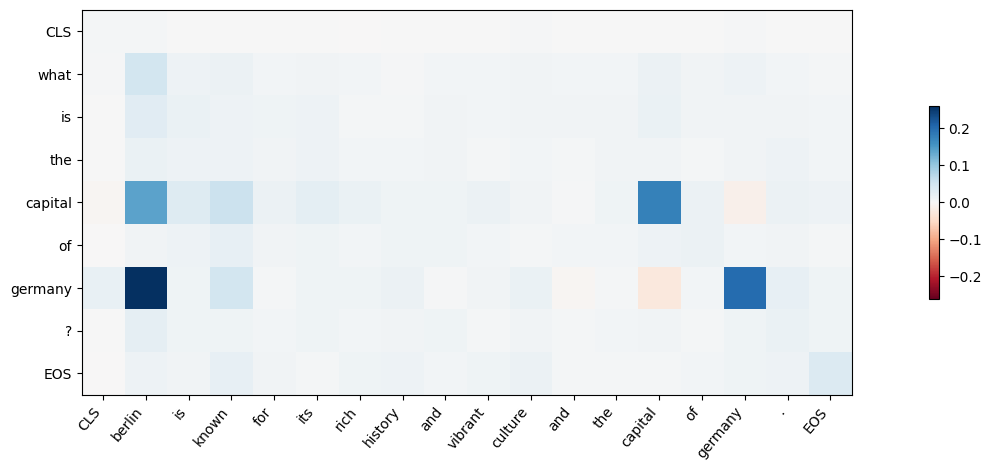

In [5]:
f = plot_attributions(
    A, 
    tokens_a, 
    tokens_b, 
    size=(20, 5), 
    range=None, 
    show_colorbar=True, 
    shrink_colorbar=.5,
)
f.show()